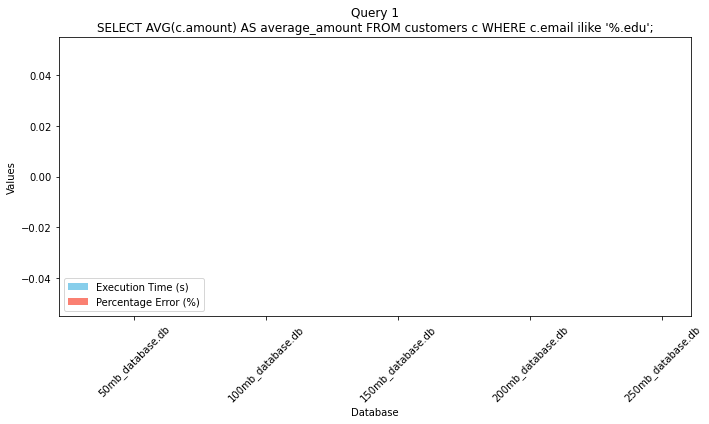

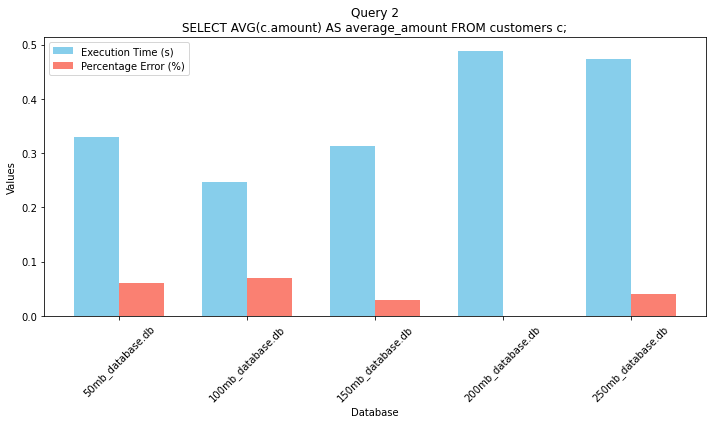

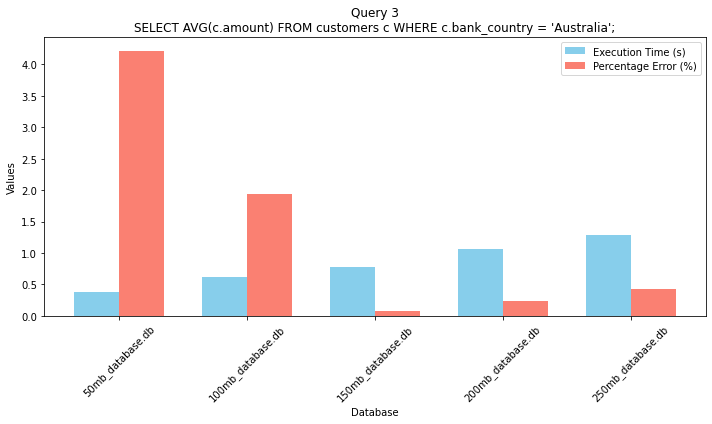

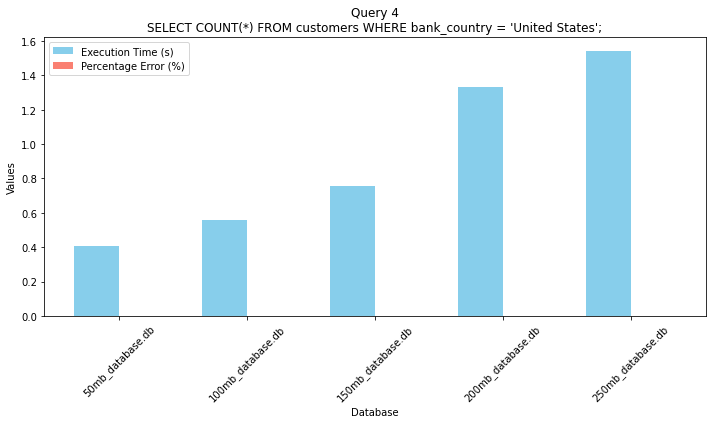

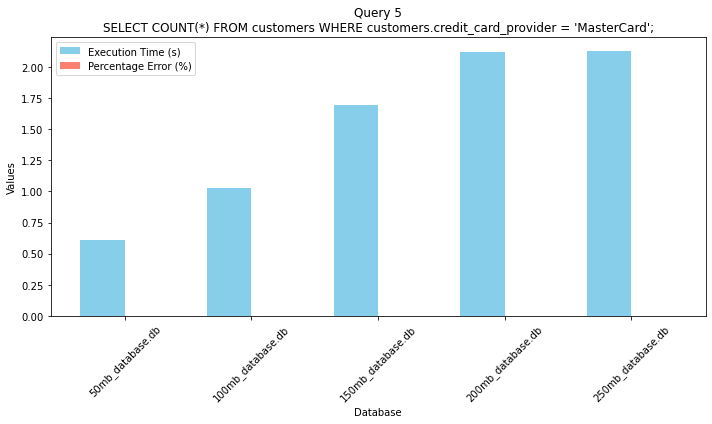

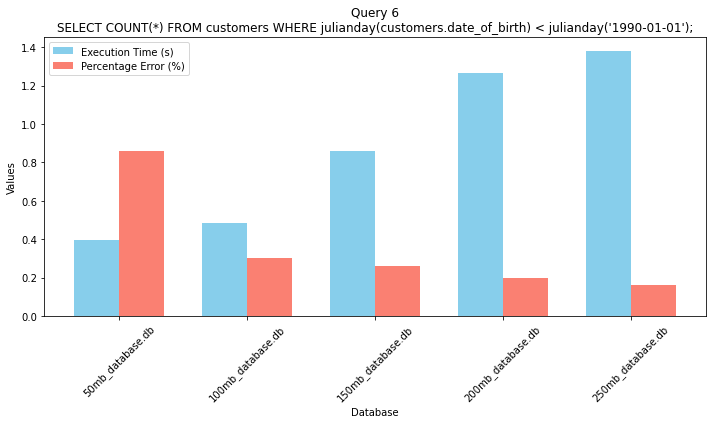

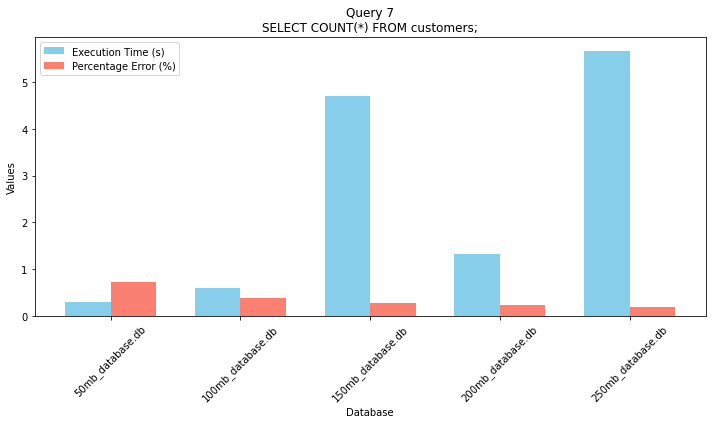

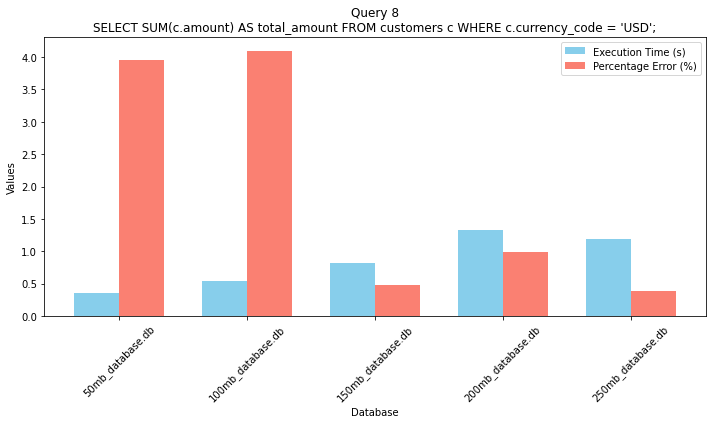

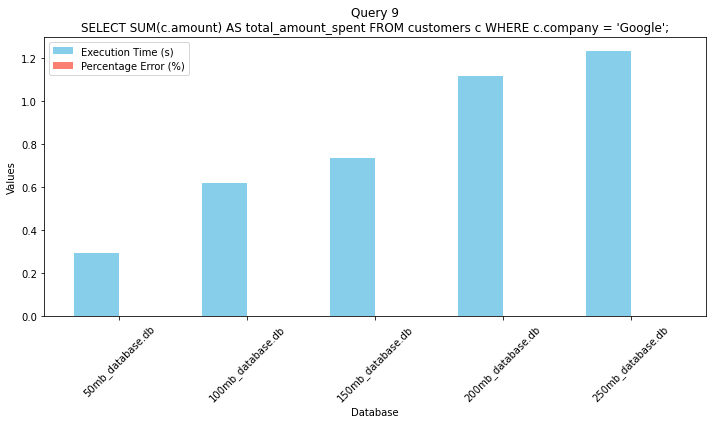

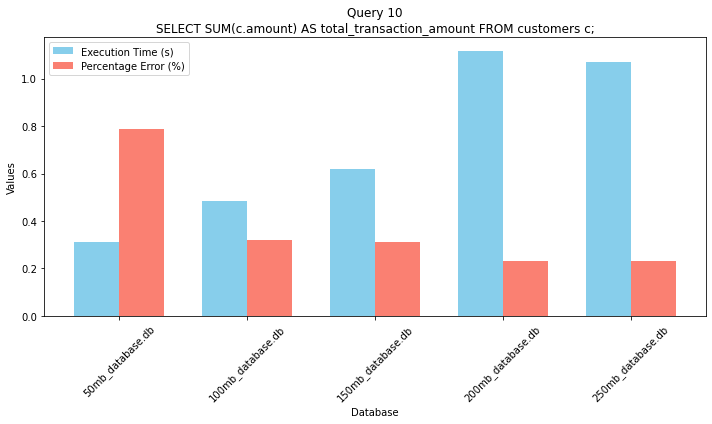

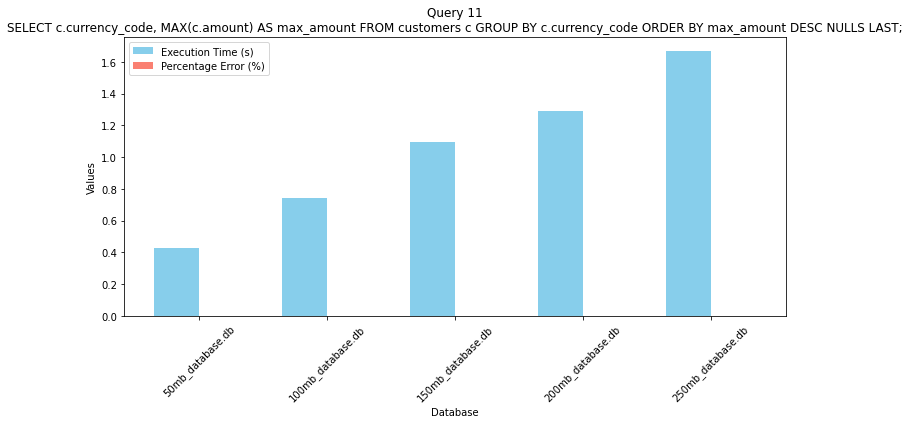

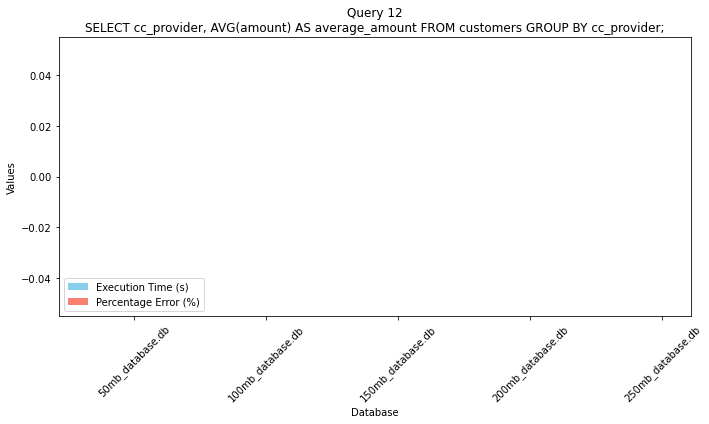

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('experiment_results.csv')
df['Percentage Error'] = df['Percentage Error'].str.replace('%', '').astype(float)
grouped = df.groupby('Query')

output_dir = 'query_charts_grouped_bars'
os.makedirs(output_dir, exist_ok=True)

for i, (query, group) in enumerate(grouped):
    x = np.arange(len(group['Database']))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    bars1 = ax.bar(x - width/2, group['Execution Time (s)'], width, label='Execution Time (s)', color='skyblue')
    bars2 = ax.bar(x + width/2, group['Percentage Error'], width, label='Percentage Error (%)', color='salmon')

    ax.set_xlabel('Database')
    ax.set_ylabel('Values')
    ax.set_title(f'Query {i+1}\n{query}')
    ax.set_xticks(x)
    ax.set_xticklabels(group['Database'], rotation=45)
    ax.legend()
    plt.tight_layout()

    plt.show()
    # plt.savefig(os.path.join(output_dir, f'query_{i+1}_grouped.jpg'))
    plt.close()

New code

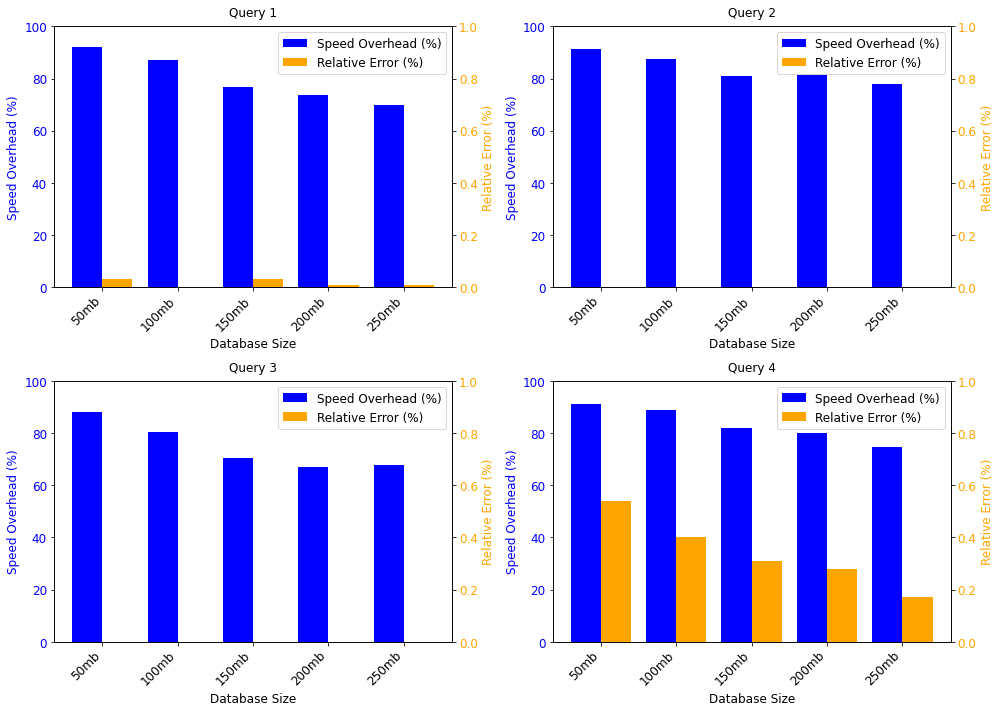

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load and clean the CSV data
df = pd.read_csv('errors_overhead_cleaned.csv')

# Handle missing or empty Relative Error values
df['Relative Error (%)'] = df['Relative Error (%)'].replace('', 0).fillna(0).astype(float)
df['Speed Overhead (%)'] = df['Speed Overhead (%)'].astype(float)

# Extract database size for X-axis labels (e.g., "50mb" from "50mb_sample.db")
df['DB_Size'] = df['Database'].str.extract(r'(\d+mb)')[0]

# Get unique queries and assign labels "Query 1", "Query 2", etc.
queries = df['Query'].unique()
query_labels = {query: f"Query {i+1}" for i, query in enumerate(queries)}

# Set up figure with subplots (2x2 grid for 4 queries)
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=False)
axes = axes.flatten()  # Flatten for easy iteration

# Plot a dual-axis bar chart for each query
for idx, query in enumerate(queries):
    # Filter data for the current query
    query_data = df[df['Query'] == query]
    
    # Prepare data
    labels = query_data['DB_Size']
    speed_overhead = query_data['Speed Overhead (%)']
    relative_error = query_data['Relative Error (%)']
    
    # Get the current axis
    ax1 = axes[idx]
    
    # Bar positions
    x = np.arange(len(labels))
    bar_width = 0.4
    
    # Plot Speed Overhead on left Y-axis
    ax1.bar(x - bar_width/2, speed_overhead, bar_width, label='Speed Overhead (%)', color='blue')
    ax1.set_ylabel('Speed Overhead (%)', fontsize=12, color='blue')
    ax1.tick_params(axis='y', labelcolor='blue', labelsize=12)
    ax1.set_ylim(0, 100)
    
    # Create right Y-axis for Relative Error
    ax2 = ax1.twinx()
    ax2.bar(x + bar_width/2, relative_error, bar_width, label='Relative Error (%)', color='orange')
    ax2.set_ylabel('Relative Error (%)', fontsize=12, color='orange')
    ax2.tick_params(axis='y', labelcolor='orange', labelsize=12)
    ax2.set_ylim(0, 1)
    
    # Customize X-axis
    ax1.set_xticks(x)
    ax1.set_xticklabels(labels, rotation=45, ha='right', fontsize=12)
    ax1.set_xlabel('Database Size', fontsize=12)
    
    # Add legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=12)
    
    # Set title using Query 1, Query 2, etc.
    ax1.set_title(query_labels[query], fontsize=12, pad=10)

# Adjust layout to prevent overlap
plt.tight_layout()

# Display the plot
plt.show()